In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = '/content/drive/My Drive/covtype.data'
df = pd.read_csv(file_path, header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,45,46,47,48,49,50,51,52,53,54
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


In [ ]:
df[54].value_counts()

,count
54,
2,283301
1,211840
3,35754
7,20510
6,17367
5,9493
4,2747


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   0       581012 non-null  int64
 1   1       581012 non-null  int64
 2   2       581012 non-null  int64
 3   3       581012 non-null  int64
 4   4       581012 non-null  int64
 5   5       581012 non-null  int64
 6   6       581012 non-null  int64
 7   7       581012 non-null  int64
 8   8       581012 non-null  int64
 9   9       581012 non-null  int64
 10  10      581012 non-null  int64
 11  11      581012 non-null  int64
 12  12      581012 non-null  int64
 13  13      581012 non-null  int64
 14  14      581012 non-null  int64
 15  15      581012 non-null  int64
 16  16      581012 non-null  int64
 17  17      581012 non-null  int64
 18  18      581012 non-null  int64
 19  19      581012 non-null  int64
 20  20      581012 non-null  int64
 21  21      581012 non-null  int64
 22  22      581012 non-n

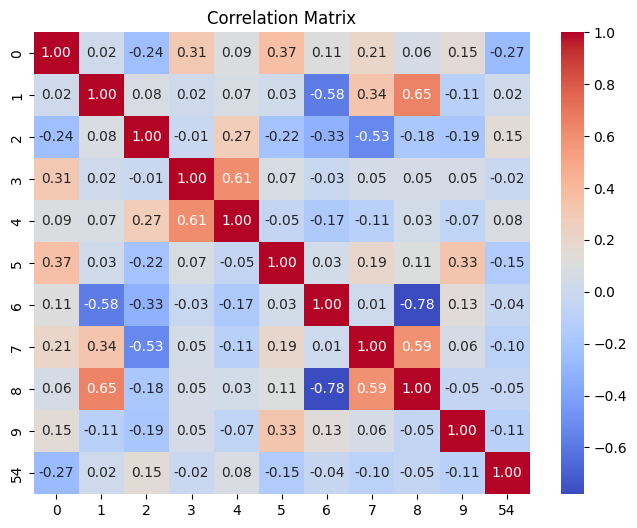

In [ ]:
cols = [0,1,2,3,4,5,6,7,8,9,54]
correlate_matrix = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlate_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

#**Feature Engineering**

In [ ]:
# Combine horizontal and vertical distances to water
df['Distance_To_Hydrology'] = np.sqrt(
    df[3]**2 +
    df[4]**2
)

In [ ]:
# How close is the point to fire vs road
df['Fire_To_Road_Ratio'] = (
    df[5] /
    (df[9] + 1)
)

In [ ]:
# How elevation and slope effect together
df['Elevation_Slope_Ratio'] = df[0] / (df[2] + 1)

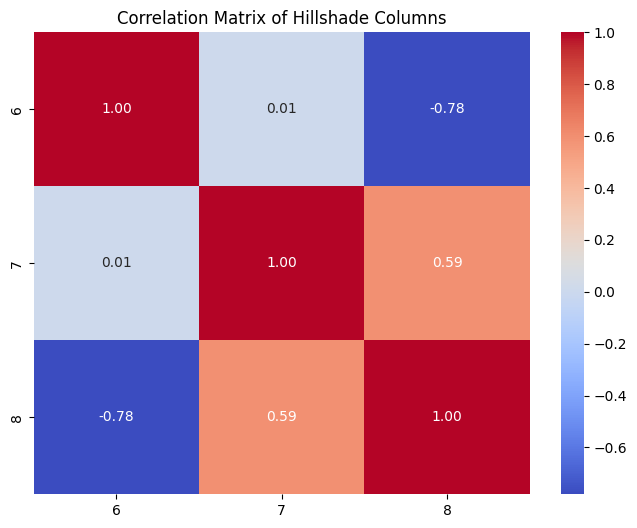

In [ ]:
hillshade_cols = [6,7,8]
correlate_matrix = df[hillshade_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlate_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Hillshade Columns')
plt.show()

In [ ]:
# Total Daily Sunlight
# df['Hillshade_Total'] = (
#     df[6] + df[7] + df[8]
# )

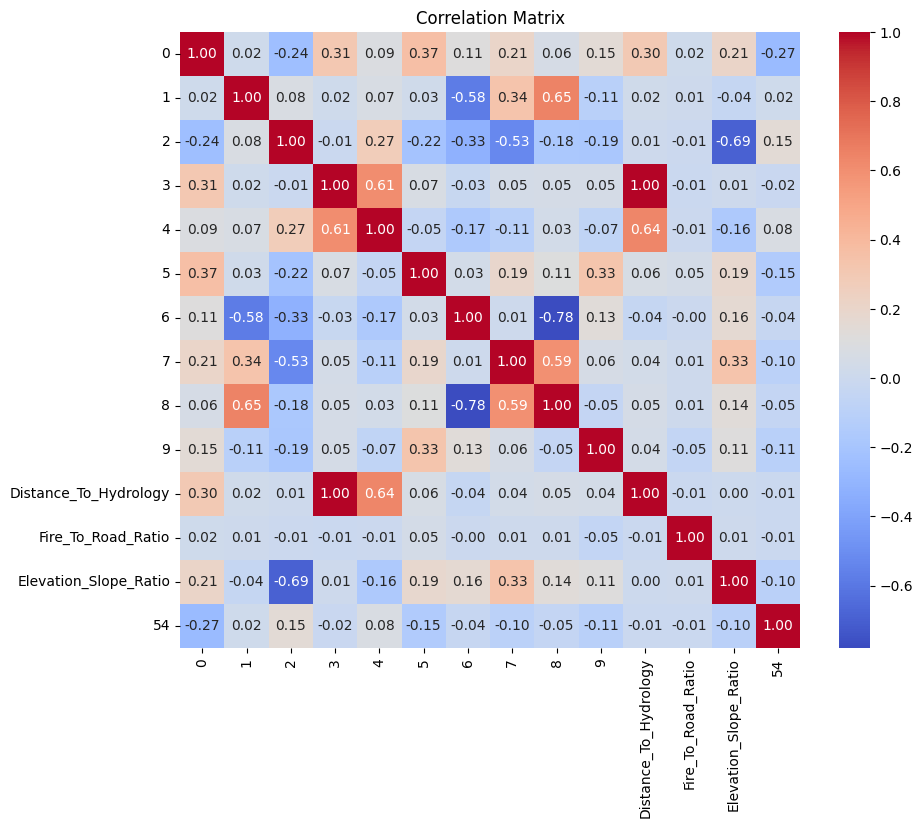

In [ ]:
cols = [0,1,2,3,4,5,6,7,8,9,'Distance_To_Hydrology','Fire_To_Road_Ratio', 'Elevation_Slope_Ratio', 54]
correlate_matrix = df[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlate_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report , confusion_matrix
from imblearn.over_sampling import SMOTE

X = df.drop(columns=[54])
y = df[54]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert column names to strings
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, class_weight = 'balanced')
rf_classifier.fit(X_train_resampled, y_train_resampled)

y_pred = rf_classifier.predict(X_test_scaled)

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Random Forest Classification Report:
              precision    recall  f1-score   support

           1       0.97      0.96      0.96     42557
           2       0.97      0.97      0.97     56500
           3       0.94      0.97      0.96      7121
           4       0.89      0.89      0.89       526
           5       0.86      0.92      0.89      1995
           6       0.91      0.94      0.92      3489
           7       0.96      0.98      0.97      4015

    accuracy                           0.96    116203
   macro avg       0.93      0.95      0.94    116203
weighted avg       0.96      0.96      0.96    116203

[[40690  1672     2     0    33     8   152]
 [ 1310 54598   181     1   242   139    29]
 [    1    32  6886    37    13   152     0]
 [    0     0    48   466     0    12     0]
 [   13   122    13     0  1838     9     0]
 [    1    31   160    21     5  3271     0]
 [   66     9     0     0     0     0  3940]]


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_classifier = DecisionTreeClassifier(random_state=42, class_weight= 'balanced')
dt_classifier.fit(X_train_resampled, y_train_resampled)

y_pred_dt = dt_classifier.predict(X_test_scaled)

print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Classification Report:
              precision    recall  f1-score   support

           1       0.94      0.94      0.94     42557
           2       0.95      0.94      0.95     56500
           3       0.92      0.93      0.93      7121
           4       0.85      0.83      0.84       526
           5       0.79      0.88      0.83      1995
           6       0.86      0.89      0.87      3489
           7       0.93      0.96      0.94      4015

    accuracy                           0.94    116203
   macro avg       0.89      0.91      0.90    116203
weighted avg       0.94      0.94      0.94    116203

[[39916  2303     4     0    52    15   267]
 [ 2493 53170   220     1   394   179    43]
 [    3   105  6656    46    27   284     0]
 [    0     1    60   439     0    26     0]
 [   36   178    12     0  1758    11     0]
 [    5    83   249    33     8  3111     0]
 [  143    13     0     0     0     0  3859]]
